In [ ]:
# ============================================================
# Molecular Subtype Cox Model (Optimized)
# ============================================================
%matplotlib inline

import os, sys, time, pickle, warnings
warnings.filterwarnings("ignore")
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import scipy.stats as st
from collections import Counter

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 6)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw
from lifelines import KaplanMeierFitter

# -----------------------
# Output directories
# -----------------------
data_dir    = "./outputs/data"
models_dir  = "./outputs/models"
plots_dir   = "./outputs/plots"
metrics_dir = "./outputs/metrics"

for d in [data_dir, models_dir, plots_dir, metrics_dir]:
    os.makedirs(d, exist_ok=True)

# -----------------------
# Helpers
# -----------------------
def bins(n):
    return max(10, int(np.sqrt(n)))

def ci(x, alpha=0.05):
    """Mean and (1-alpha) t-interval; returns (mean, halfwidth, lo, hi)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    m = float(np.mean(x))
    if n < 2:
        return round(m, 3), np.nan, np.nan, np.nan
    se = st.sem(x)
    tcrit = st.t.ppf(1 - alpha / 2, df=n - 1)
    hw = float(tcrit * se)
    return round(m, 3), round(hw, 3), round(m - hw, 3), round(m + hw, 3)

def timeit(start_time):
    t = time.time() - start_time
    return f"{t:.1f}s" if t < 60 else f"{t/60:.1f}min"

def harrell_cindex(y, pred):
    return concordance_index_censored(
        y["Event"], y["Progression Free Survival"], pred
    )[0]

def uno_cindex(y_train, y_test, pred):
    try:
        tau = np.percentile(y_train["Progression Free Survival"], 90)
        return concordance_index_ipcw(y_train, y_test, pred, tau=tau)[0]
    except ValueError:
        print("  ⚠️ Uno's C-index failed for this fold (censoring survival = 0), returning NaN")
        return np.nan

def harrell_cv_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return harrell_cindex(y, pred)


# 1. Load Data and Model

In [2]:

# ============================================================
# 1. Load Data
# ============================================================
X_molecular = pd.read_pickle("./X_molecular.pkl")
y_df        = pd.read_pickle("./y.pkl")

tmp = X_molecular.merge(
    y_df.drop(columns="Cohort"), left_index=True, right_index=True
)

X_all  = tmp.drop(columns=["Progression Free Survival", "Event"])
cohort = y_df["Cohort"]
X_all["Cohort"] = cohort

X_discovery = X_all[X_all["Cohort"] == "Discovery"].drop(columns="Cohort")
X_replicate = X_all[X_all["Cohort"] == "Replicate"].drop(columns="Cohort")

y_discovery = np.array(
    [(bool(e), float(t)) for e, t in tmp.loc[X_discovery.index, ["Event", "Progression Free Survival"]].values],
    dtype=[("Event", "?"), ("Progression Free Survival", "<f8")],
)
y_replicate = np.array(
    [(bool(e), float(t)) for e, t in tmp.loc[X_replicate.index, ["Event", "Progression Free Survival"]].values],
    dtype=[("Event", "?"), ("Progression Free Survival", "<f8")],
)

print("Discovery:", X_discovery.shape, "Replicate:", X_replicate.shape)
print("Discovery events:", int(np.sum(y_discovery["Event"])),
      "Replicate events:", int(np.sum(y_replicate["Event"])))

Discovery: (428, 9) Replicate: (65, 9)
Discovery events: 118 Replicate events: 30


# 2. Discovery

## 2.1 Train and Test

In [3]:

# ============================================================
# 2. Nested Cross-Validation
# ============================================================

# Uniform penalty across all molecular features
molecular_penalty = 1
penalty_factor = np.ones(X_discovery.shape[1], dtype=float) * molecular_penalty

# Adaptive folds based on event count
n_events = int(np.sum(y_discovery["Event"]))
if n_events < 10:
    n_splits = 3
elif n_events < 20:
    n_splits = 5
else:
    n_splits = 10

outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using n_splits={n_splits} (events={n_events})")

l1_grid = np.arange(0.1, 1.01, 0.1).tolist()
n_alphas        = 100
alpha_min_ratio = 0.1
max_iter        = 50000
alpha_floor     = None
n_jobs          = 1

cv_rows = []
outer_s = time.time()

for fold_idx, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_discovery, y_discovery["Event"]), start=1
):
    fold_s = time.time()

    X_train = X_discovery.iloc[train_idx, :]
    X_test  = X_discovery.iloc[test_idx, :]
    y_train = y_discovery[train_idx]
    y_test  = y_discovery[test_idx]

    inner_splits       = list(inner_cv.split(X_train, y_train["Event"]))
    best_model         = None
    best_inner_harrell = -np.inf
    best_params        = None

    for l1 in l1_grid:
        path_model = CoxnetSurvivalAnalysis(
            l1_ratio=l1,
            penalty_factor=penalty_factor,
            n_alphas=n_alphas,
            alpha_min_ratio=alpha_min_ratio,
            fit_baseline_model=True,
            max_iter=max_iter,
        )
        path_model.fit(X_train, y_train)
        alphas = np.array(path_model.alphas_, dtype=float)

        if alpha_floor is not None:
            alphas = alphas[alphas >= alpha_floor]
        if len(alphas) == 0:
            continue

        base = CoxnetSurvivalAnalysis(
            l1_ratio=l1,
            penalty_factor=penalty_factor,
            fit_baseline_model=True,
            max_iter=max_iter,
        )

        gcv = GridSearchCV(
            estimator=base,
            param_grid={"alphas": [[a] for a in alphas]},
            scoring=harrell_cv_scorer,
            cv=inner_splits,
            n_jobs=n_jobs,
            refit=True,
            error_score=np.nan,
            return_train_score=False,
        )
        gcv.fit(X_train, y_train)

        score = gcv.best_score_
        if score is None or (isinstance(score, float) and np.isnan(score)):
            continue

        score = float(score)
        if score > best_inner_harrell:
            best_inner_harrell = score
            best_model  = gcv.best_estimator_
            best_params = {
                "l1_ratio": float(l1),
                "alpha":    float(gcv.best_params_["alphas"][0]),
            }

    if best_model is None:
        raise RuntimeError(
            f"Fold {fold_idx}: all candidate fits failed. "
            f"Try increasing alpha_min_ratio or setting alpha_floor."
        )

    pred_test = best_model.predict(X_test)
    har = harrell_cindex(y_test, pred_test)
    uno = uno_cindex(y_train, y_test, pred_test)

    cv_rows.append({
        "fold":           fold_idx,
        "best_estimator": best_model,
        "inner_harrell":  best_inner_harrell,
        "harrell":        har,
        "uno":            uno,
        "best_l1_ratio":  best_params["l1_ratio"],
        "best_alpha":     best_params["alpha"],
    })

    print(
        f"Fold {fold_idx}/{n_splits} in {timeit(fold_s)} | "
        f"Harrell={har:.3f} Uno={uno} | "
        f"inner(Harrell)={best_inner_harrell:.3f} | "
        f"l1_ratio={best_params['l1_ratio']:.2f}, alpha={best_params['alpha']:.4g}"
    )

cv_results = pd.DataFrame(cv_rows)
print(f"\nNested CV finished in {timeit(outer_s)}")

n_jobs = -1

# Print and save CV metrics
scorings     = ["harrell", "uno"]
metrics_text = []
for scoring in scorings:
    c, u, l, h = ci(cv_results[scoring])
    metric_str  = f"{scoring}: {c}  CI: +/-{u}  [{l}, {h}]"
    print(metric_str)
    metrics_text.append(metric_str)

with open(os.path.join(metrics_dir, "cv_metrics.txt"), "w") as f:
    f.write("\n".join(metrics_text))

cv_results.to_csv(os.path.join(metrics_dir, "cv_results.csv"), index=False)

Using n_splits=10 (events=118)
Fold 1/10 in 13.5s | Harrell=0.578 Uno=0.542354112149051 | inner(Harrell)=0.533 | l1_ratio=0.80, alpha=0.004905
Fold 2/10 in 13.4s | Harrell=0.530 Uno=0.5466237891799461 | inner(Harrell)=0.545 | l1_ratio=0.10, alpha=0.0205
Fold 3/10 in 13.1s | Harrell=0.596 Uno=0.5007478440390025 | inner(Harrell)=0.553 | l1_ratio=0.20, alpha=0.01028
Fold 4/10 in 13.1s | Harrell=0.524 Uno=0.5118077874195524 | inner(Harrell)=0.550 | l1_ratio=0.30, alpha=0.01265
Fold 5/10 in 13.4s | Harrell=0.391 Uno=0.37833150269426047 | inner(Harrell)=0.537 | l1_ratio=0.10, alpha=0.04919
Fold 6/10 in 13.1s | Harrell=0.592 Uno=0.5799134025890214 | inner(Harrell)=0.537 | l1_ratio=0.20, alpha=0.009864
Fold 7/10 in 13.0s | Harrell=0.608 Uno=0.5235809572488018 | inner(Harrell)=0.538 | l1_ratio=0.20, alpha=0.008598
Fold 8/10 in 13.0s | Harrell=0.573 Uno=0.5480146811259217 | inner(Harrell)=0.520 | l1_ratio=0.10, alpha=0.0394
Fold 9/10 in 13.2s | Harrell=0.403 Uno=0.4925032524345058 | inner(Harrel

# 3. Final Model 


In [4]:
# Most frequent l1_ratio across folds
l1_counts      = Counter(cv_results["best_l1_ratio"].tolist())
final_l1_ratio = l1_counts.most_common(1)[0][0]

# Median alpha from folds that used that dominant l1_ratio
final_alpha = float(
    cv_results.loc[cv_results["best_l1_ratio"] == final_l1_ratio, "best_alpha"].median()
)

print(f"\nl1_ratio counts across folds: {dict(l1_counts)}")
print(f"Final l1_ratio (dominant):              {final_l1_ratio}")
print(f"Final alpha (median of matching folds): {final_alpha:.4g}")

estimator = CoxnetSurvivalAnalysis(
    l1_ratio=final_l1_ratio,
    alphas=[final_alpha],
    penalty_factor=penalty_factor,
    fit_baseline_model=True,
    max_iter=max_iter,
)
estimator.fit(X_discovery, y_discovery)

final_coef = np.asarray(estimator.coef_).reshape(-1)
print(f"Nonzero features: {int(np.sum(np.abs(final_coef) > 1e-12))}")

with open(os.path.join(models_dir, "estimator.pkl"), "wb") as f:
    pickle.dump(estimator, f)
print(f"Saved estimator -> {models_dir}/estimator.pkl")

with open(os.path.join(metrics_dir, "final_hyperparameters.txt"), "w") as f:
    f.write(f"l1_ratio counts across folds: {dict(l1_counts)}\n")
    f.write(f"Final l1_ratio: {final_l1_ratio}\n")
    f.write(f"Final alpha: {final_alpha}\n")


l1_ratio counts across folds: {0.8: 1, 0.1: 5, 0.2: 3, 0.30000000000000004: 1}
Final l1_ratio (dominant):              0.1
Final alpha (median of matching folds): 0.0394
Nonzero features: 5
Saved estimator -> ./outputs/models/estimator.pkl


# 4. Discovery Risk Scores & Stratification

Median threshold: -0.04390203544849609


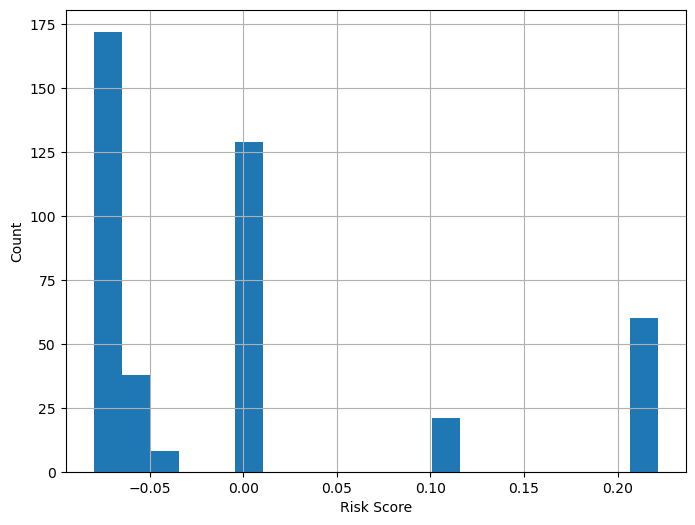

T-statistic: 23.1860, p-value: 0.0000


In [11]:
risk_discovery = pd.DataFrame(
    {"Risk Score": estimator.predict(X_discovery)},
    index=X_discovery.index
)
risk_discovery["Event"] = y_discovery["Event"].astype(int)
risk_discovery["Progression Free Survival"] = y_discovery["Progression Free Survival"].astype(float)

median_threshold = float(risk_discovery["Risk Score"].median())
risk_discovery["Risk Group"] = np.where(
    risk_discovery["Risk Score"] > median_threshold, "High", "Low"
)

with open(os.path.join(data_dir, "discovery_results.pkl"), "wb") as f:
    pickle.dump(risk_discovery, f)
with open(os.path.join(data_dir, "risk_threshold.pkl"), "wb") as f:
    pickle.dump({"median_threshold": median_threshold}, f)

#  Also save threshold as txt
with open(os.path.join(metrics_dir, "risk_thresholds.txt"), "w") as f:
    f.write(f"Risk categorization: Low vs High\n")
    f.write(f"Threshold (50th percentile/median): {median_threshold}\n")
    f.write(f"Low: Risk Score <= {median_threshold}\n")
    f.write(f"High: Risk Score > {median_threshold}\n")
    
# Also save as CSV
risk_discovery.to_csv(os.path.join(data_dir, "discovery_results.csv"), index=True)

print(f"Median threshold: {median_threshold}")

plt.figure(figsize=(8, 6))
risk_discovery["Risk Score"].hist(bins=bins(risk_discovery.shape[0]))
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.savefig(os.path.join(plots_dir, "discovery_risk_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

from scipy.stats import ttest_ind
high_scores = risk_discovery[risk_discovery["Risk Group"] == "High"]["Risk Score"]
low_scores  = risk_discovery[risk_discovery["Risk Group"] == "Low"]["Risk Score"]
t_stat, p_val = ttest_ind(high_scores, low_scores)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

with open(os.path.join(metrics_dir, "ttest_results.txt"), "w") as f:
    f.write(f"Independent t-test (High vs Low Risk)\n")
    f.write(f"T-statistic: {t_stat}\n")
    f.write(f"p-value: {p_val}\n")
    f.write(f"Median threshold: {median_threshold}\n")

# 5. Bootstrap Uncertainty Quantification


Bootstrapping 500 fits...
Done. Failed fits: 0/500 (0.0%)


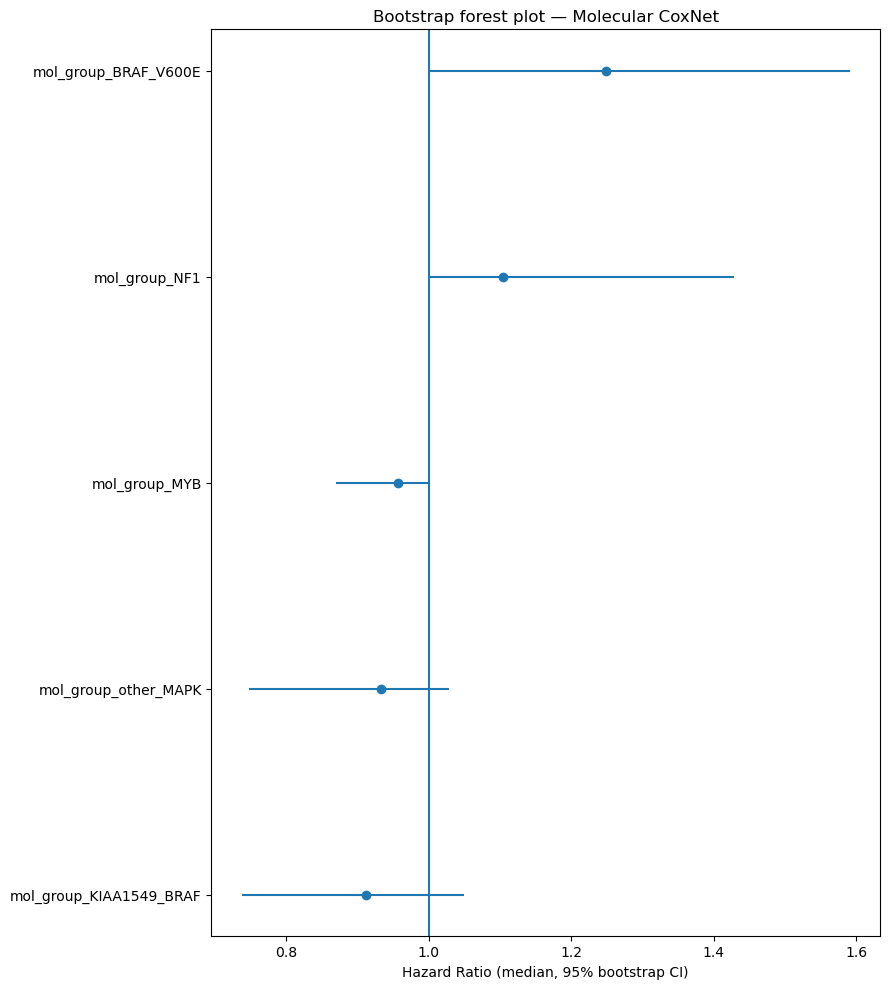

                             coef        HR
mol_group_BRAF_V600E     0.216027  1.241136
mol_group_NF1            0.102005  1.107389
mol_group_MYB           -0.049346  0.951852
mol_group_other_MAPK    -0.062874  0.939062
mol_group_KIAA1549_BRAF -0.085173  0.918354


In [12]:

B    = 500
seed = 42
rng  = np.random.default_rng(seed)
tol  = 1e-12

feature_names = X_discovery.columns.to_list()
p             = len(feature_names)
coef_boot     = np.full((B, p), np.nan, dtype=float)
failed        = 0
n             = X_discovery.shape[0]

print(f"\nBootstrapping {B} fits...")

for b in range(B):
    idx = rng.integers(0, n, size=n)
    Xb  = X_discovery.iloc[idx, :]
    yb  = y_discovery[idx]

    model_b = CoxnetSurvivalAnalysis(
        l1_ratio=final_l1_ratio,
        alphas=[final_alpha],
        penalty_factor=penalty_factor,
        fit_baseline_model=False,
        max_iter=max_iter,
    )
    try:
        model_b.fit(Xb, yb)
        coef_boot[b, :] = np.asarray(model_b.coef_).reshape(-1)
    except Exception:
        failed += 1
        continue

print(f"Done. Failed fits: {failed}/{B} ({failed/B:.1%})")

ok      = ~np.isnan(coef_boot).all(axis=1)
coef_ok = coef_boot[ok, :]
B_ok    = coef_ok.shape[0]

if B_ok < 30:
    raise RuntimeError(f"Too few successful bootstrap fits ({B_ok}).")

sel_freq = (np.abs(coef_ok) > tol).mean(axis=0)
coef_med = np.nanmedian(coef_ok, axis=0)
coef_lo  = np.nanpercentile(coef_ok, 2.5, axis=0)
coef_hi  = np.nanpercentile(coef_ok, 97.5, axis=0)
hr_med   = np.exp(coef_med)
hr_lo    = np.exp(coef_lo)
hr_hi    = np.exp(coef_hi)

forest = pd.DataFrame({
    "Feature":             feature_names,
    "Selection_Frequency": sel_freq,
    "Coef_Median":         coef_med,
    "Coef_2.5%":           coef_lo,
    "Coef_97.5%":          coef_hi,
    "HR_Median":           hr_med,
    "HR_2.5%":             hr_lo,
    "HR_97.5%":            hr_hi,
})

final_nonzero              = np.abs(final_coef) > tol
forest["Nonzero_in_Final"] = final_nonzero
forest_filt                = forest[forest["Nonzero_in_Final"]].copy()
forest_filt                = forest_filt.sort_values("Selection_Frequency", ascending=False)
forest_filt.to_csv(os.path.join(data_dir, "bootstrap_forest.csv"), index=False)

if len(forest_filt) > 0:
    top  = forest_filt.head(25).copy().sort_values("HR_Median")
    ypos = np.arange(len(top))

    plt.figure(figsize=(9, 10))
    plt.errorbar(
        top["HR_Median"], ypos,
        xerr=[top["HR_Median"] - top["HR_2.5%"], top["HR_97.5%"] - top["HR_Median"]],
        fmt="o"
    )
    plt.axvline(1.0)
    plt.yticks(ypos, top["Feature"])
    plt.xlabel("Hazard Ratio (median, 95% bootstrap CI)")
    plt.title("Bootstrap forest plot — Molecular CoxNet")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("⚠️ No nonzero features in final model — forest plot skipped.")

coef_vec = np.asarray(estimator.coef_).reshape(-1)
coef_df  = pd.DataFrame({"coef": coef_vec}, index=X_discovery.columns)
coef_df  = coef_df.loc[np.abs(coef_df["coef"]) > tol].copy()

if len(coef_df) > 0:
    coef_df["HR"] = np.exp(coef_df["coef"])
    coef_df = coef_df.sort_values("HR", ascending=False)
    coef_df.to_csv(os.path.join(data_dir, "coef_hr_table.csv"))
    print(coef_df)
else:
    print("⚠️ No nonzero coefficients in final model.")

Bootstrapping 500 fits...
Done. Failed fits: 0/500 (0.0%)
Successful fits: 500/500
Selected features: 5
Univariate fits — successful: 5, failed: 0


,Feature,Selection_Frequency,HR_Median,HR_2.5%,HR_97.5%,HR_uni,p_display
0,mol_group_BRAF_V600E,0.952,1.248301,1.000000,1.590791,1.727,p=0.018
3,mol_group_NF1,0.792,1.104570,1.000000,1.428540,1.800,p=0.091
1,mol_group_KIAA1549_BRAF,0.862,0.912307,0.737712,1.049123,0.784,p=0.205
4,mol_group_other_MAPK,0.768,0.933545,0.747262,1.027844,0.689,p=0.311
2,mol_group_MYB,0.800,0.956234,0.870318,1.000000,0.000,p=0.993


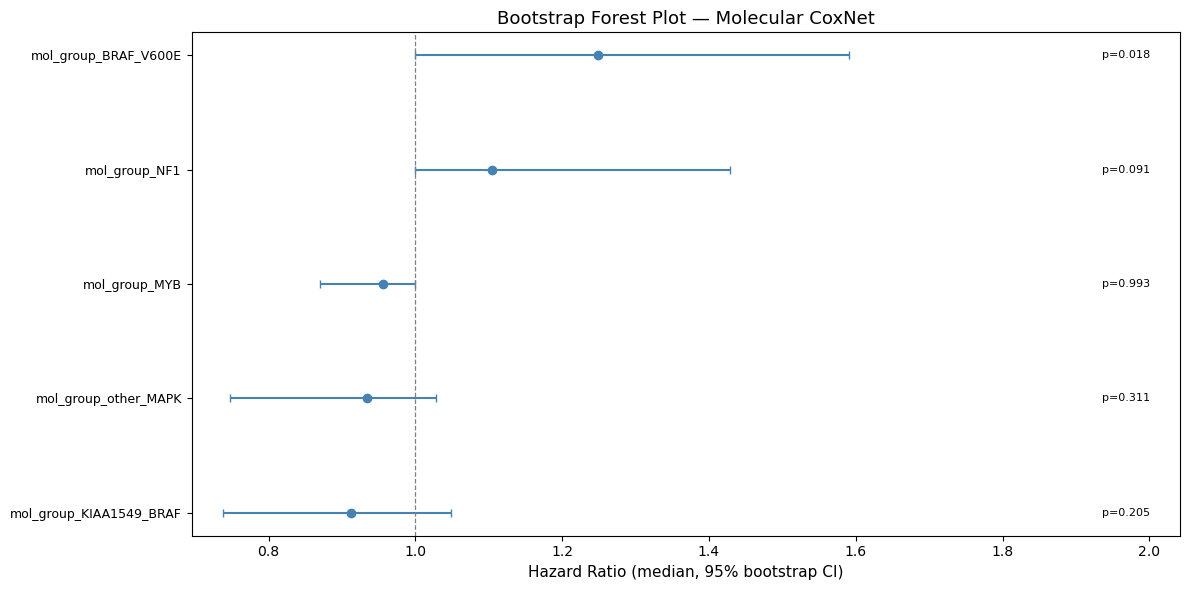

                             coef        HR
mol_group_BRAF_V600E     0.216027  1.241136
mol_group_NF1            0.102005  1.107389
mol_group_MYB           -0.049346  0.951852
mol_group_other_MAPK    -0.062874  0.939062
mol_group_KIAA1549_BRAF -0.085173  0.918354


In [15]:
# ============================================================
# BOOTSTRAP + FOREST PLOT — MOLECULAR COXNET
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sksurv.linear_model import CoxnetSurvivalAnalysis
from lifelines import CoxPHFitter

# -----------------------
# Settings
# -----------------------
B    = 500
seed = 42
rng  = np.random.default_rng(seed)
tol  = 1e-12

feature_names = X_discovery.columns.to_list()
p             = len(feature_names)
n             = X_discovery.shape[0]
coef_boot     = np.full((B, p), np.nan, dtype=float)
failed        = 0

# -----------------------
# Bootstrap fits
# -----------------------
print(f"Bootstrapping {B} fits...")
for b in range(B):
    idx = rng.integers(0, n, size=n)
    Xb  = X_discovery.iloc[idx, :]
    yb  = y_discovery[idx]

    model_b = CoxnetSurvivalAnalysis(
        l1_ratio=final_l1_ratio,
        alphas=[final_alpha],
        penalty_factor=penalty_factor,
        fit_baseline_model=False,
        max_iter=max_iter,
    )
    try:
        model_b.fit(Xb, yb)
        coef_boot[b, :] = np.asarray(model_b.coef_).reshape(-1)
    except Exception:
        failed += 1
        continue

print(f"Done. Failed fits: {failed}/{B} ({failed/B:.1%})")

# -----------------------
# Bootstrap summaries
# -----------------------
ok      = ~np.isnan(coef_boot).all(axis=1)
coef_ok = coef_boot[ok, :]
B_ok    = coef_ok.shape[0]

if B_ok < 30:
    raise RuntimeError(f"Too few successful bootstrap fits ({B_ok}).")

print(f"Successful fits: {B_ok}/{B}")

sel_freq = (np.abs(coef_ok) > tol).mean(axis=0)
coef_med = np.nanmedian(coef_ok,           axis=0)
coef_lo  = np.nanpercentile(coef_ok,  2.5, axis=0)
coef_hi  = np.nanpercentile(coef_ok, 97.5, axis=0)
hr_med   = np.exp(coef_med)
hr_lo    = np.exp(coef_lo)
hr_hi    = np.exp(coef_hi)

# -----------------------
# Build forest table
# -----------------------
final_coef    = np.asarray(estimator.coef_).reshape(-1)
final_nonzero = np.abs(final_coef) > tol

forest = pd.DataFrame({
    "Feature"            : feature_names,
    "Selection_Frequency": sel_freq,
    "Coef_Median"        : coef_med,
    "Coef_2.5%"          : coef_lo,
    "Coef_97.5%"         : coef_hi,
    "HR_Median"          : hr_med,
    "HR_2.5%"            : hr_lo,
    "HR_97.5%"           : hr_hi,
    "Nonzero_in_Final"   : final_nonzero,
})

forest_filt = forest[forest["Nonzero_in_Final"]].copy()
forest_filt = forest_filt.sort_values("Selection_Frequency", ascending=False)

if len(forest_filt) == 0:
    print("No nonzero features in final model — stopping here.")
else:
    print(f"Selected features: {len(forest_filt)}")

    # -----------------------
    # Univariate Cox p-values
    # -----------------------
    uni_results  = []
    failed_feats = []

    for feat in forest_filt["Feature"].tolist():
        try:
            df_uni = pd.DataFrame({
                "T"    : y_discovery["Progression Free Survival"],
                "E"    : y_discovery["Event"].astype(int),
                "feat" : X_discovery[feat].values,
            })
            cph = CoxPHFitter()
            cph.fit(df_uni, duration_col="T", event_col="E")
            row = cph.summary.loc["feat"]
            uni_results.append({
                "Feature"   : feat,
                "HR_uni"    : round(float(row["exp(coef)"]),           3),
                "HR_lo_uni" : round(float(row["exp(coef) lower 95%"]), 3),
                "HR_hi_uni" : round(float(row["exp(coef) upper 95%"]), 3),
                "p_uni"     : float(row["p"]),
            })
        except Exception as e:
            failed_feats.append(feat)
            print(f"  FAILED univariate: {feat} -> {e}")

    print(f"Univariate fits — successful: {len(uni_results)}, failed: {len(failed_feats)}")

    uni_df      = pd.DataFrame(uni_results)
    forest_filt = forest_filt.merge(uni_df, on="Feature", how="left")

    def fmt_p(p):
        if pd.isna(p): return "NA"
        if p < 0.001:  return "p<0.001"
        else:          return f"p={p:.3f}"

    forest_filt["p_display"] = forest_filt["p_uni"].apply(fmt_p)
    forest_filt.to_csv(os.path.join(data_dir, "bootstrap_forest.csv"), index=False)
    display(
            forest_filt.sort_values("p_uni")[[
                "Feature", "Selection_Frequency",
                "HR_Median", "HR_2.5%", "HR_97.5%",
                "HR_uni", "p_display"
            ]]
        )

    # -----------------------
    # Forest plot
    # -----------------------
    top  = forest_filt.sort_values("Selection_Frequency", ascending=False).head(25).copy()
    top  = top.sort_values("HR_Median")
    ypos = np.arange(len(top))

    fig, ax = plt.subplots(figsize=(12, max(6, len(top) * 1.1)))

    for i, (_, row) in enumerate(top.iterrows()):
        ax.errorbar(
            row["HR_Median"], i,
            xerr=[[row["HR_Median"] - row["HR_2.5%"]],
                  [row["HR_97.5%"] - row["HR_Median"]]],
            fmt="o", color="steelblue", capsize=3, markersize=6
        )

    ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.9)
    ax.set_yticks(ypos)
    ax.set_yticklabels(top["Feature"], fontsize=9)
    ax.set_xlabel("Hazard Ratio (median, 95% bootstrap CI)", fontsize=11)
    ax.set_title("Bootstrap Forest Plot — Molecular CoxNet", fontsize=13)

    # Widen x-axis for p-value annotations
    x_lo, x_hi = ax.get_xlim()
    ax.set_xlim(x_lo, x_hi * 1.25)
    x_right = ax.get_xlim()[1]

    for i, (_, row) in enumerate(top.iterrows()):
        ax.text(
            x_right * 0.98, i,
            row["p_display"],
            va="center", ha="right", fontsize=8
        )

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -----------------------
    # Coefficient / HR table
    # -----------------------
    coef_df = pd.DataFrame({"coef": final_coef}, index=X_discovery.columns)
    coef_df = coef_df.loc[np.abs(coef_df["coef"]) > tol].copy()
    coef_df["HR"] = np.exp(coef_df["coef"])
    coef_df = coef_df.sort_values("HR", ascending=False)
    coef_df.to_csv(os.path.join(data_dir, "coef_hr_table.csv"))
    print(coef_df)

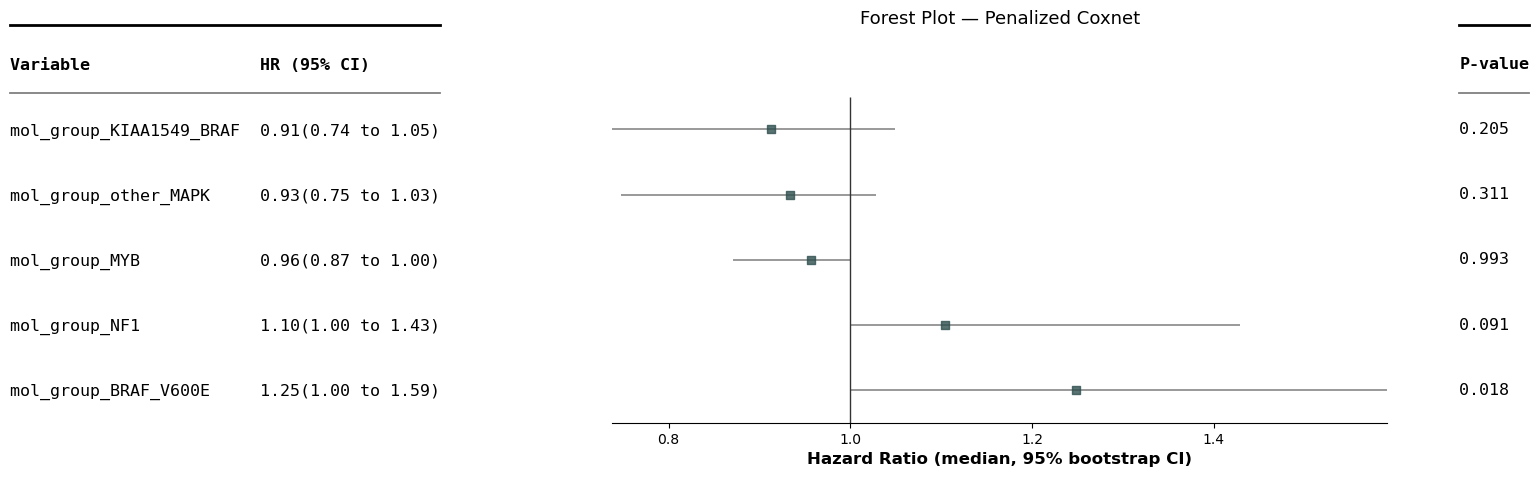

In [22]:
# ============================================================
# FOREST PLOT USING forestplot PACKAGE
# ============================================================
import forestplot as fp

# -----------------------
# Prepare dataframe
# -----------------------
fp_df = forest_filt.copy()

fp_df["estimate"] = fp_df["HR_Median"]
fp_df["ll"]       = fp_df["HR_2.5%"]
fp_df["hl"]       = fp_df["HR_97.5%"]
fp_df["varlabel"] = fp_df["Feature"]
fp_df["p_uni"]    = fp_df["p_uni"].astype(float)

# CI string: "0.91 (0.74 to 1.05)"
fp_df["est_ci"] = (
    fp_df["HR_Median"].round(2).astype(str)
    + " ("
    + fp_df["HR_2.5%"].round(2).astype(str)
    + " to "
    + fp_df["HR_97.5%"].round(2).astype(str)
    + ")"
)

# Pre-formatted p-value string
fp_df["pval_display"] = fp_df["p_uni"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

# Sort by HR
fp_df = fp_df.sort_values("estimate")

# -----------------------
# Plot
# -----------------------
ax = fp.forestplot(
    fp_df,
    estimate="estimate",
    ll="ll",
    hl="hl",
    varlabel="varlabel",
    pval="p_uni",
    starpval=False,
    ci_report=False,                      # we supply our own CI string
    annote=["est_ci"],                    # left table: our CI string
    annoteheaders=["HR (95% CI)"],
    rightannote=["pval_display"],         # right table: p-value
    right_annoteheaders=["P-value"],
    xlabel="Hazard Ratio (median, 95% bootstrap CI)",
    xline=1.0,
    table=True,                           # <-- enables the clean table layout
    figsize=(10, 5),

)

ax.set_title("Forest Plot — Penalized Coxnet", pad=10, fontsize=13)
plt.savefig(os.path.join(plots_dir, "bootstrap_forest_plot.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 6. Replicate Evaluation

In [7]:
pred_rep = estimator.predict(X_replicate)

har = harrell_cindex(y_replicate, pred_rep)
uno = uno_cindex(y_discovery, y_replicate, pred_rep)  

print(f"\nReplicate Harrell C-index: {har:.4f}")
print(f"Replicate Uno C-index:     {uno}")

with open(os.path.join(metrics_dir, "replicate_metrics.txt"), "w") as f:
    f.write(f"Harrell's C-index: {har:.6f}\n")
    f.write(f"Uno's C-index (IPCW weights from discovery): {uno}\n")



Replicate Harrell C-index: 0.5337
Replicate Uno C-index:     0.45659883176476307


# 7. Replicate Risk Scores & Stratification

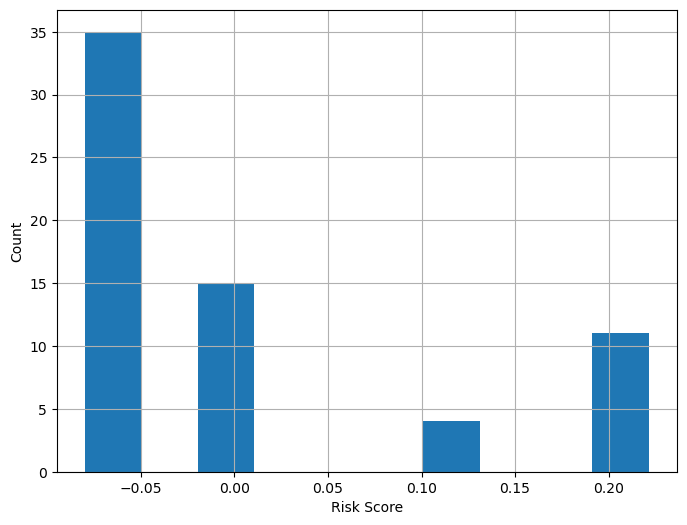

In [8]:
with open(os.path.join(data_dir, "risk_threshold.pkl"), "rb") as f:
    median_threshold = pickle.load(f)["median_threshold"]

risk_replicate = pd.DataFrame(
    {"Risk Score": estimator.predict(X_replicate)},
    index=X_replicate.index
)
risk_replicate["Event"] = y_replicate["Event"].astype(int)
risk_replicate["Progression Free Survival"] = y_replicate["Progression Free Survival"].astype(float)

risk_replicate["Risk Group"] = np.where(
    risk_replicate["Risk Score"] > median_threshold, "High", "Low"
)

with open(os.path.join(data_dir, "replicate_results.pkl"), "wb") as f:
    pickle.dump(risk_replicate, f)

# ✅ Also save as CSV
risk_replicate.to_csv(os.path.join(data_dir, "replicate_results.csv"), index=True)

plt.figure(figsize=(8, 6))
risk_replicate["Risk Score"].hist(bins=bins(risk_replicate.shape[0]))
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.savefig(os.path.join(plots_dir, "replicate_risk_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [10]:
# ── T-test: Risk Group separation ────────────────────────────────────────
high_scores = risk_replicate[risk_replicate["Risk Group"] == "High"]["Risk Score"]
low_scores  = risk_replicate[risk_replicate["Risk Group"] == "Low"]["Risk Score"]

t_stat, p_val = ttest_ind(high_scores, low_scores)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
print(f"High risk n={len(high_scores)}, Low risk n={len(low_scores)}")

with open(os.path.join(metrics_dir, "replicate_ttest_results.txt"), "w") as f:
    f.write(f"Independent t-test (High vs Low Risk) — Replicate\n")
    f.write(f"T-statistic: {t_stat}\n")
    f.write(f"p-value: {p_val}\n")
    f.write(f"Median threshold (from discovery): {median_threshold}\n")
    f.write(f"High risk n: {len(high_scores)}\n")
    f.write(f"Low risk n: {len(low_scores)}\n")

T-statistic: 10.2468, p-value: 0.0000
High risk n=30, Low risk n=35


# 8. Combine & Save All Risk Scores


In [9]:
risk = pd.concat([risk_discovery, risk_replicate], axis=0)
risk["Cohort"] = (
    ["Discovery"] * risk_discovery.shape[0] +
    ["Replicate"]  * risk_replicate.shape[0]
)
risk.to_csv(os.path.join(data_dir, "risk_scores.csv"), index=True)
print("Saved combined risk scores.")

Saved combined risk scores.
